# ЛЗ-6. Ықтималдық мерзім болжамы: Монте-Карло

**Жоба:** Съёмка.kz  
**Команда:** Айтказинов Арсен және Ерденбаев Адильжан, АЖ-41  

Бұл notebook 10 MVP-тарихшаның аяқталу мерзімін 10 000 рет модельдейді. Съёмка.kz командасында әлі аяқталған тарихшалар жеткіліксіз болғандықтан, throughput қатары [оқу әдістемесіндегі мысалдан](https://docs.google.com/document/d/1YnEduQa17Q5hHZx4rnQzN4EjeLB51pN_/edit) алынды. Сондықтан нәтиже оқу болжамы болып саналады; бірінші екі спринттен кейін қатарды өзіміздің нақты throughput деректерімен ауыстыру қажет.

Қайта орындау үшін: `pip install numpy matplotlib`, содан кейін ұяшықтарды жоғарыдан төмен қарай іске қосыңыз.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from datetime import date, timedelta

THROUGHPUT = np.array([4, 6, 0, 7, 5, 2, 6, 9, 4, 5, 0, 6, 7, 4, 5, 1, 6, 5, 9, 3, 4, 6, 5, 8, 2, 5])
BACKLOG_SIZE, RUNS, SEED = 10, 10_000, 42
START_DATE = date(2026, 10, 12)
rng = np.random.default_rng(SEED)
weeks = np.empty(RUNS, dtype=int)
for run in range(RUNS):
    done, week = 0, 0
    while done < BACKLOG_SIZE:
        done += rng.choice(THROUGHPUT)
        week += 1
    weeks[run] = week
print(f'Исторических наблюдений: {len(THROUGHPUT)}; средний throughput: {THROUGHPUT.mean():.2f} историй/нед.')
print(f'Прогонов: {RUNS}; размер прогнозируемого backlog: {BACKLOG_SIZE} историй')

Исторических наблюдений: 26; средний throughput: 4.77 историй/нед.
Прогонов: 10000; размер прогнозируемого backlog: 10 историй


In [ ]:
percentiles = {p: int(np.percentile(weeks, p)) for p in (50, 70, 85, 95)}
for p, week in percentiles.items():
    finish = START_DATE + timedelta(days=week * 7 - 3)
    print(f'P{p}: {week} недели, ориентировочно до {finish:%d.%m.%Y}')

P50: 2 недели, ориентировочно до 23.10.2026
P70: 3 недели, ориентировочно до 30.10.2026
P85: 3 недели, ориентировочно до 30.10.2026
P95: 4 недели, ориентировочно до 06.11.2026


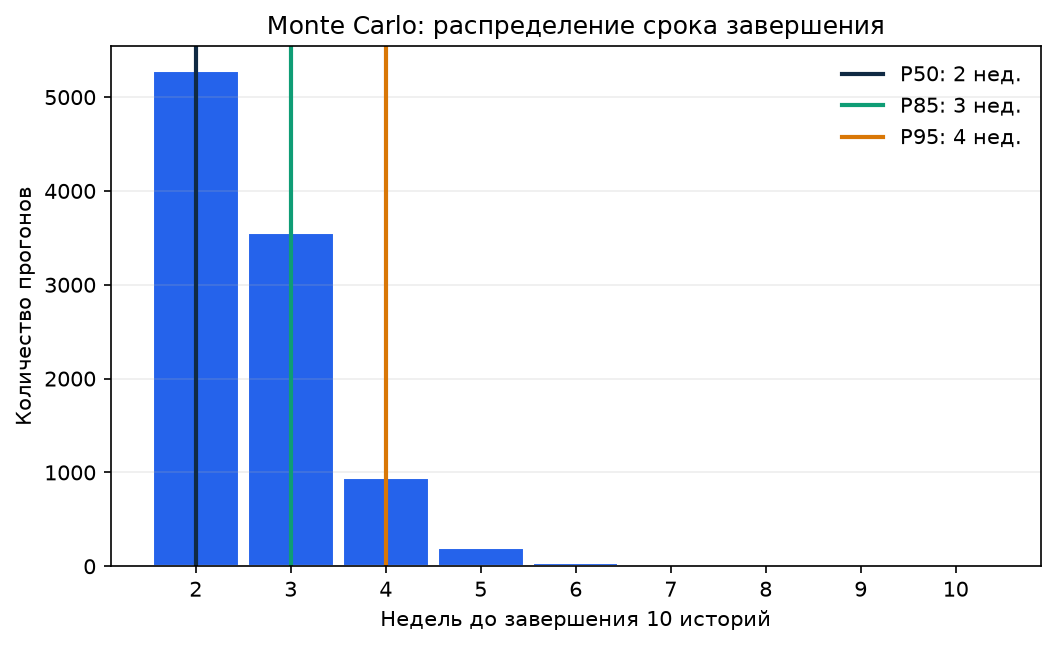

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4.5))
bins = np.arange(weeks.min() - 0.5, weeks.max() + 1.5, 1)
ax.hist(weeks, bins=bins, color='#2563EB', edgecolor='white', rwidth=0.9)
for p, color in ((50, '#102A43'), (85, '#0F9D75'), (95, '#D97706')):
    ax.axvline(percentiles[p], color=color, linewidth=2, label=f'P{p}: {percentiles[p]} нед.')
ax.set(title='Monte Carlo: распределение срока завершения', xlabel='Недель до завершения', ylabel='Количество прогонов')
ax.legend(frameon=False); ax.grid(axis='y', alpha=0.22); plt.show()

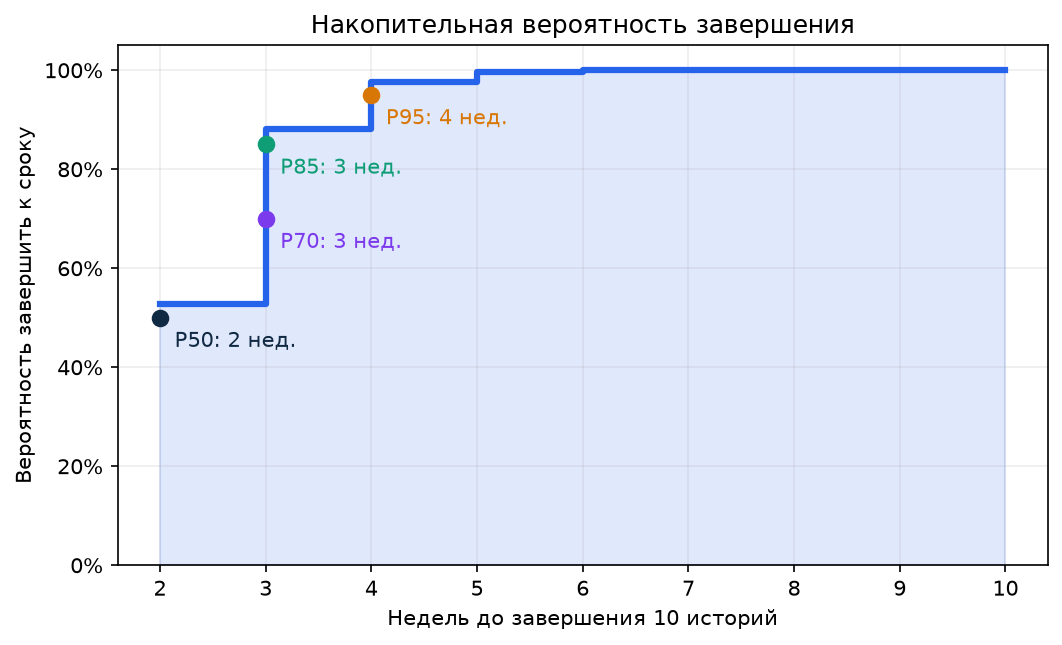

In [ ]:
values = np.arange(weeks.min(), weeks.max() + 1)
cdf = np.array([(weeks <= value).mean() for value in values])
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.step(values, cdf, where='post', color='#2563EB', linewidth=3)
ax.fill_between(values, cdf, step='post', color='#2563EB', alpha=0.14)
for p in (50, 70, 85, 95):
    ax.scatter([percentiles[p]], [p/100], s=55)
    ax.annotate(f'P{p}: {percentiles[p]} нед.', (percentiles[p], p/100), xytext=(7, -14), textcoords='offset points')
ax.set(title='Накопительная вероятность завершения', xlabel='Недель до завершения', ylabel='Вероятность завершить к сроку', ylim=(0, 1.05))
ax.grid(alpha=0.22); plt.show()

## Сравнение с детерминистической оценкой

Планировочный покер для десяти историй дал 32 story points. При учебном допущении 16 SP в неделю детерминистическая оценка составляет **2 недели**. Monte Carlo показывает, что такая дата соответствует примерно P50: она вероятна, но не является безопасным обязательством. Для обещания заказчику выбран P85: **3 недели, до 30.10.2026**, если работа начнётся 12.10.2026 и команда сохраняет сопоставимый throughput.